# Task 2 — ESRI 10 m Land Use Land Cover Map

**Study Area:** Rhine Gorge (Mittelrheintal), Germany  
**Product:** ESRI Annual Land Cover `io-lulc-annual-v02` (Sentinel-2, 10 m)  
**Source:** Microsoft Planetary Computer STAC API

This notebook downloads the ESRI LULC tile for the AOI, clips and reprojects it to match the Landsat scene, displays it with a legend, and saves it as CNN ground truth for Task 4.

In [30]:
!pip install rasterio numpy matplotlib shapely requests --quiet


In [20]:
import os, json, warnings, requests
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.crs import CRS
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_geom
from rasterio.mask import mask as rio_mask
from rasterio.merge import merge as rio_merge
from shapely.geometry import box, mapping, shape

print('Libraries loaded.')


Libraries loaded.


In [31]:
# Universal path-safety block - ensures we can find the project root and config regardless of where this script is run from.

import os, json

def find_project_root(start=None):
    current = start or os.path.abspath('.')
    for _ in range(8):
        if os.path.isdir(os.path.join(current, 'data', 'landsat')):
            return current
        current = os.path.dirname(current)
    raise FileNotFoundError('Could not find project root — is data/landsat/ present?')

PROJECT_ROOT = find_project_root()
CONFIG_PATH  = os.path.join(PROJECT_ROOT, 'data', 'landsat', 'band_paths.json')

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH) as f:
        cfg = json.load(f)

    SCENE_ID  = cfg.get('scene_id', '')
    SCENE_DIR = os.path.join(PROJECT_ROOT, 'data', 'landsat', SCENE_ID)

    BAND_SUFFIXES = {
        'band2_blue' : '_SR_B2.TIF',
        'band3_green': '_SR_B3.TIF',
        'band4_red'  : '_SR_B4.TIF',
        'band5_nir'  : '_SR_B5.TIF',
        'band6_swir1': '_SR_B6.TIF',
        'band7_swir2': '_SR_B7.TIF',
    }

    if os.path.isdir(SCENE_DIR):
        scene_files = os.listdir(SCENE_DIR)
        for key, suffix in BAND_SUFFIXES.items():
            if not os.path.exists(cfg.get(key, '')):  # only fix if broken
                for fname in scene_files:
                    if fname.upper().endswith(suffix.upper()):
                        cfg[key] = os.path.join(SCENE_DIR, fname)
                        break

    if 'esri_lulc' in cfg:
        LULC_DIR = os.path.join(PROJECT_ROOT, 'data', 'esri_lulc')
        for key, fname in {
            'clipped_path'      : 'esri_lulc_rhine_gorge_clipped.tif',
            'reprojected_path'  : 'esri_lulc_rhine_gorge_utm32n.tif',
            'clipped_to_landsat': 'esri_lulc_clipped_to_landsat.tif',
        }.items():
            full = os.path.join(LULC_DIR, fname)
            if not os.path.exists(cfg['esri_lulc'].get(key, '')):
                cfg['esri_lulc'][key] = full

    if 'ndvi' in cfg:
        ndvi_path = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'ndvi_rhine_gorge.tif')
        if not os.path.exists(cfg['ndvi'].get('tif_path', '')):
            cfg['ndvi']['tif_path'] = ndvi_path

    with open(CONFIG_PATH, 'w') as f:
        json.dump(cfg, f, indent=2)

    print(f'✓  Project root : {PROJECT_ROOT}')
    print(f'✓  Config       : {CONFIG_PATH}')

else:
    print(f'✓  Project root : {PROJECT_ROOT}')
    print('   Config not yet created — will be written by Notebook 01.')

✓  Project root : c:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY
✓  Config       : c:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\band_paths.json


## Step 1 — Load config from Task 1

In [33]:
CONFIG_PATH = '../data/landsat/band_paths.json'

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

aoi         = cfg['aoi']
AOI_MIN_LON = aoi['min_lon'];  AOI_MAX_LON = aoi['max_lon']
AOI_MIN_LAT = aoi['min_lat'];  AOI_MAX_LAT = aoi['max_lat']
CENTRE_LAT  = aoi['centre_lat'];  CENTRE_LON = aoi['centre_lon']
AREA_KM2    = aoi['area_km2']
SCENE_ID    = cfg['scene_id'];  SCENE_DATE  = cfg['scene_date']
BAND4_RED   = cfg['band4_red']

os.makedirs('../data/esri_lulc', exist_ok=True)
os.makedirs('../data/outputs',   exist_ok=True)

print(f'AOI  : {aoi["name"]}')
print(f'Bbox : {AOI_MIN_LON:.4f}°E - {AOI_MAX_LON:.4f}°E  |  {AOI_MIN_LAT:.4f}°N - {AOI_MAX_LAT:.4f}°N')
print(f'Scene: {SCENE_ID}  ({SCENE_DATE})')

AOI  : Rhine Gorge (Mittelrheintal) — Loreley AOI
Bbox : 7.6793°E - 7.7787°E  |  50.1021°N - 50.1659°N
Scene: LC81960252021153LGN00  (unknown)


## Step 2 — Define ESRI LULC colour scheme

In [34]:
LULC_CLASSES = {
    1:  ('Water',              '#1A5BAB'),
    2:  ('Trees',              '#358221'),
    3:  ('Grass / Shrub',      '#8DC33B'),
    4:  ('Flooded vegetation', '#87D19E'),
    5:  ('Crops',              '#FFDB5C'),
    7:  ('Built area',         '#ED022A'),
    8:  ('Bare ground',        '#EDE9E4'),
    9:  ('Snow / Ice',         '#F2FAFF'),
    10: ('Clouds',             '#C8C8C8'),
    11: ('Rangeland',          '#E8D44D'),
}
MAX_CLASS   = 11
color_array = ['#000000'] * (MAX_CLASS + 1)
for code, (_, hx) in LULC_CLASSES.items():
    color_array[code] = hx
LULC_CMAP = mcolors.ListedColormap(color_array)
LULC_NORM = mcolors.BoundaryNorm(boundaries=list(range(MAX_CLASS + 2)), ncolors=MAX_CLASS + 1)
print('Colour scheme ready.')

Colour scheme ready.


## Step 3 — Download ESRI LULC via ArcGIS REST API

We download the ESRI 10 m Land Cover directly from the **ArcGIS Living Atlas ImageServer** using the `exportImage` endpoint.  
A server-side `mosaicRule` filters strictly to `TARGET_YEAR` — no STAC client, no tile merging needed.


In [35]:
TARGET_YEAR = 2022

esri_url = "https://ic.imagery1.arcgis.com/arcgis/rest/services/Sentinel2_10m_LandCover/ImageServer/exportImage"

params = {
    "bbox"      : f"{AOI_MIN_LON},{AOI_MIN_LAT},{AOI_MAX_LON},{AOI_MAX_LAT}",
    "bboxSR"    : 4326,
    "size"      : "1024,1024",
    "imageSR"   : 4326,
    "format"    : "tiff",
    "pixelType" : "U8",
    "noData"    : 255,
    "mosaicRule": json.dumps({"mosaicMethod": "esriMosaicAttribute",
                              "sortField": "Year",
                              "where": f"Year={TARGET_YEAR}"}),
    "f"         : "image"
}

raw_path = '../data/esri_lulc/esri_lulc_rhine_gorge_raw.tif'
resp = requests.get(esri_url, params=params)
resp.raise_for_status()
with open(raw_path, 'wb') as fh:
    fh.write(resp.content)
print(f'Downloaded ({os.path.getsize(raw_path)/1e6:.1f} MB) → {raw_path}')


Downloaded (1.0 MB) → ../data/esri_lulc/esri_lulc_rhine_gorge_raw.tif


## Step 4 — Reproject & clip to Landsat extent

`nodata=255` is used at every stage — no valid ESRI class equals 255.


In [36]:
CLIPPED_PATH            = '../data/esri_lulc/esri_lulc_rhine_gorge_clipped.tif'
REPROJECTED_PATH        = '../data/esri_lulc/esri_lulc_rhine_gorge_utm32n.tif'
LULC_CLIPPED_TO_LANDSAT = '../data/esri_lulc/esri_lulc_clipped_to_landsat.tif'
TARGET_CRS              = CRS.from_epsg(32632)   # UTM Zone 32N

# reproject to UTM 32N 
with rasterio.open(raw_path) as src:
    t_out, w_out, h_out = calculate_default_transform(
        src.crs, TARGET_CRS, src.width, src.height, *src.bounds)
    meta_out = src.meta.copy()
    meta_out.update({'crs': TARGET_CRS, 'transform': t_out,
                     'width': w_out, 'height': h_out, 'nodata': 255})
    with rasterio.open(REPROJECTED_PATH, 'w', **meta_out) as dst:
        reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                  src_crs=src.crs, dst_crs=TARGET_CRS,
                  resampling=Resampling.nearest, src_nodata=255, dst_nodata=255)
print(f'Reprojected to UTM 32N: {w_out} × {h_out} px')

# clip to exact Landsat extent 
from rasterio.warp import transform_bounds as tb

# Load the band path fresh from config in case BAND4_RED wasn't set correctly
with open('../data/landsat/band_paths.json') as f:
    _cfg = json.load(f)
band4_path = _cfg.get('band4_red') or _cfg['bands']['B4']

l_left, l_bottom, l_right, l_top = tb(
    CRS.from_epsg(4326), TARGET_CRS,
    AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)

with rasterio.open(REPROJECTED_PATH) as src:
    safe_box = box(l_left, l_bottom, l_right, l_top).intersection(box(*src.bounds))
    if safe_box.is_empty:
        raise ValueError('AOI does not overlap LULC raster — check coordinates.')
    clipped2, clip2_transform = rio_mask(src, [mapping(safe_box)], crop=True, nodata=255)
    meta2 = src.meta.copy()
    meta2.update({'height': clipped2.shape[1], 'width': clipped2.shape[2],
                  'transform': clip2_transform, 'nodata': 255})
with rasterio.open(LULC_CLIPPED_TO_LANDSAT, 'w', **meta2) as dst:
    dst.write(clipped2)
print(f'Clipped to Landsat extent: {clipped2.shape[2]} × {clipped2.shape[1]} px')
print('All LULC processing complete.')


Reprojected to UTM 32N: 804 × 1231 px
Clipped to Landsat extent: 798 × 795 px
All LULC processing complete.


## Step 5 — Display ESRI LULC map with legend  *(Assessment 2a)*

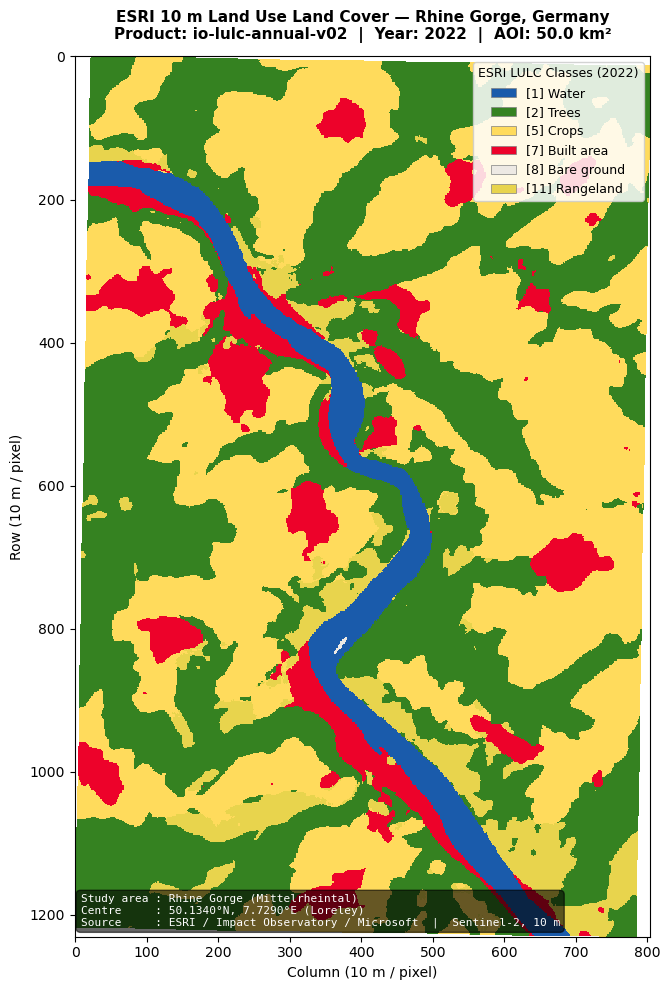

Saved → esri_lulc_rhine_gorge.png


In [37]:
with rasterio.open(REPROJECTED_PATH) as src:
    lulc_arr    = src.read(1)
    lulc_res    = src.res[0]

lulc_display = lulc_arr.astype(float)
lulc_display[lulc_display == 255] = np.nan

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(lulc_display, cmap=LULC_CMAP, norm=LULC_NORM, interpolation='none')
ax.set_title(
    f'ESRI 10 m Land Use Land Cover — Rhine Gorge, Germany\n'
    f'Product: io-lulc-annual-v02  |  Year: {TARGET_YEAR}  |  AOI: {AREA_KM2:.1f} km²',
    fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Column (10 m / pixel)', fontsize=10)
ax.set_ylabel('Row (10 m / pixel)', fontsize=10)

present_codes = [int(c) for c in np.unique(lulc_arr[lulc_arr != 255])]
ax.legend(
    handles=[mpatches.Patch(facecolor=LULC_CLASSES[c][1], edgecolor='grey', linewidth=0.5,
                             label=f'[{c}] {LULC_CLASSES[c][0]}')
             for c in sorted(present_codes) if c in LULC_CLASSES],
    title='ESRI LULC Classes (2022)', title_fontsize=9, fontsize=9,
    loc='upper right', framealpha=0.85)
ax.text(0.01, 0.01,
    f'Study area : Rhine Gorge (Mittelrheintal)\n'
    f'Centre     : {CENTRE_LAT:.4f}°N, {CENTRE_LON:.4f}°E (Loreley)\n'
    f'Source     : ESRI / Impact Observatory / Microsoft  |  Sentinel-2, 10 m',
    transform=ax.transAxes, fontsize=8, color='white', family='monospace',
    va='bottom', bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.4'))
plt.tight_layout()
plt.savefig('../data/outputs/esri_lulc_rhine_gorge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → esri_lulc_rhine_gorge.png')

## Step 6 — Side-by-side: True Color vs LULC  *(Assessment 2b)*

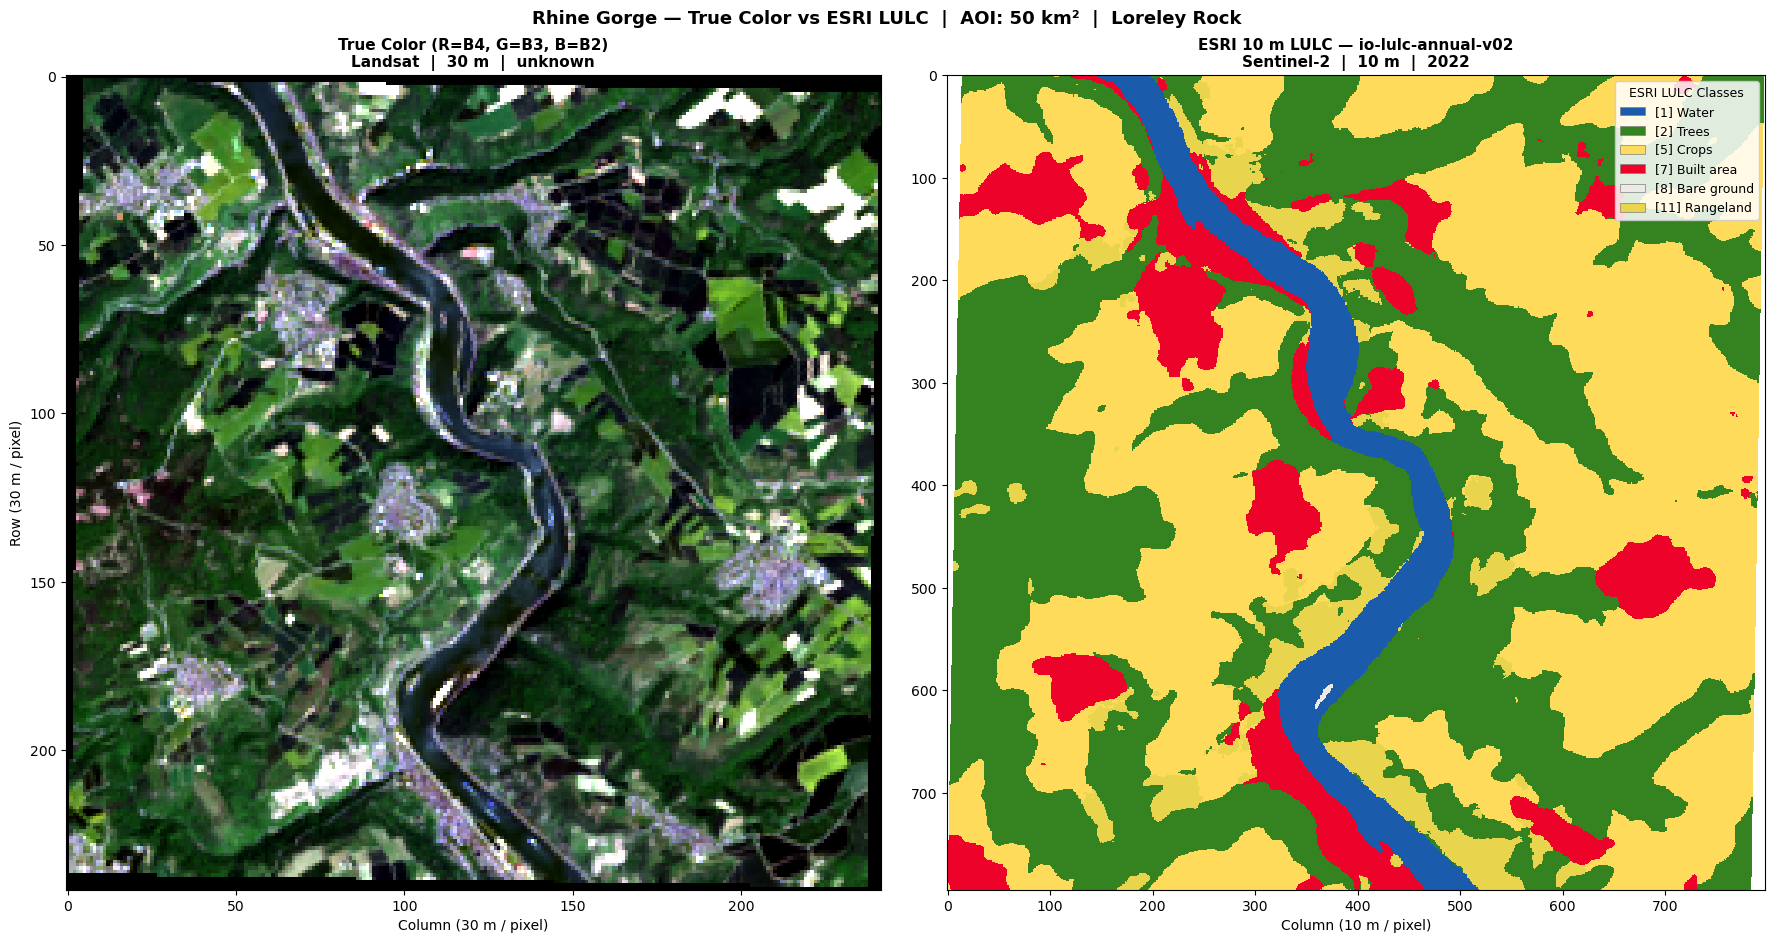

Saved → truecolor_vs_lulc_rhine_gorge.png


In [ ]:
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds as win_from_bounds

def load_band_clipped(filepath, min_lon, min_lat, max_lon, max_lat):
    """Load and clip a Landsat C2 L2 band with AOI safety intersection."""
    aoi_geom_wgs84 = box(min_lon, min_lat, max_lon, max_lat)
    with rasterio.open(filepath) as src:
        # Reproject AOI into raster CRS, then intersect with raster bounds
        # to avoid loading data that doesn't overlap the AOI at all (common with small AOIs)
        aoi_native  = shape(transform_geom('EPSG:4326', src.crs.to_wkt(), mapping(aoi_geom_wgs84)))
        raster_bbox = box(*src.bounds)
        aoi_safe    = aoi_native.intersection(raster_bbox)
        if aoi_safe.is_empty:
            raise ValueError(f'AOI does not overlap raster: {filepath}')
        clipped, _ = rio_mask(src, [mapping(aoi_safe)], crop=True, nodata=0)
        raw = clipped[0].astype(np.float32)
        # Also get window-based transform for GeoTIFF saving
        left, bottom, right, top = transform_bounds(
            CRS.from_epsg(4326), src.crs, min_lon, min_lat, max_lon, max_lat)
        window        = win_from_bounds(left, bottom, right, top, src.transform)
        win_transform = src.window_transform(window)
        crs_out       = src.crs
    fill_mask   = (raw < 7273) | (raw > 65455)
    reflectance = np.clip(raw * 0.0000275 - 0.2, 0.0, 1.0)
    reflectance[fill_mask] = np.nan
    return reflectance, win_transform, crs_out

def pct_stretch(band, lo=2, hi=98):
    v = band[~np.isnan(band)]
    p_lo, p_hi = np.percentile(v, lo), np.percentile(v, hi)
    return np.clip((band - p_lo) / (p_hi - p_lo + 1e-9), 0, 1)

r, _, _ = load_band_clipped(cfg['band4_red'],   AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
g, _, _ = load_band_clipped(cfg['band3_green'], AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
b, _, _ = load_band_clipped(cfg['band2_blue'],  AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)

# Band shape safety trim — all bands must match 
shapes = [r.shape, g.shape, b.shape]
if len(set(shapes)) > 1:
    min_r = min(s[0] for s in shapes); min_c = min(s[1] for s in shapes)
    r, g, b = r[:min_r, :min_c], g[:min_r, :min_c], b[:min_r, :min_c]
    print(f'Bands trimmed to {min_r}×{min_c} due to minor shape mismatch')

rgb_image = np.nan_to_num(np.dstack([pct_stretch(r), pct_stretch(g), pct_stretch(b)]), nan=0.0)

with rasterio.open(LULC_CLIPPED_TO_LANDSAT) as src:
    lulc_plot = src.read(1).astype(float)
lulc_plot[lulc_plot == 255] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(rgb_image.astype(np.float32))
axes[0].set_title(f'True Color (R=B4, G=B3, B=B2)\nLandsat  |  30 m  |  {SCENE_DATE}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Column (30 m / pixel)'); axes[0].set_ylabel('Row (30 m / pixel)')

axes[1].imshow(lulc_plot, cmap=LULC_CMAP, norm=LULC_NORM, interpolation='none')
axes[1].set_title(f'ESRI 10 m LULC — io-lulc-annual-v02\nSentinel-2  |  10 m  |  {TARGET_YEAR}',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Column (10 m / pixel)')
axes[1].legend(
    handles=[mpatches.Patch(facecolor=LULC_CLASSES[c][1], edgecolor='grey', linewidth=0.5,
                             label=f'[{c}] {LULC_CLASSES[c][0]}')
             for c in sorted([int(c) for c in np.unique(lulc_plot[~np.isnan(lulc_plot)])]) if c in LULC_CLASSES],
    title='ESRI LULC Classes', title_fontsize=9, fontsize=9, loc='upper right', framealpha=0.85)

fig.suptitle('Rhine Gorge — True Color vs ESRI LULC  |  AOI: 50 km²  |  Loreley Rock',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/outputs/truecolor_vs_lulc_rhine_gorge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → truecolor_vs_lulc_rhine_gorge.png')

## Step 7 — Class distribution & save config

In [39]:
import os

landsat_dir = r'C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat'
print(f'landsat_dir exists: {os.path.exists(landsat_dir)}')
print()

for root, dirs, files in os.walk(landsat_dir):
    for f in files:
        if f.endswith('.TIF') or f.endswith('.tif'):
            print(os.path.join(root, f))

landsat_dir exists: True

C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_QA_PIXEL.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_QA_RADSAT.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_SR_B1.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_SR_B2.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_SR_B3.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_SR_B4.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\LC81960252021153LGN00\LC08_L2SP_196025_20210602_20210608_02_T1_SR_B5.TIF
C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\

In [40]:
with rasterio.open(LULC_CLIPPED_TO_LANDSAT) as src:
    lulc_analysis = src.read(1)

valid_pixels = lulc_analysis[lulc_analysis != 255]
total_valid  = len(valid_pixels)

print(f'LULC Class Distribution — Rhine Gorge AOI')
print(f'Total valid pixels: {total_valid:,}  ({total_valid * 100 / 1e6:.2f} km²)')
print(f'\n{"Code":<6} {"Class":<22} {"Pixels":>10} {"Area km²":>10} {"Cover"}')
print('─' * 62)
for code in sorted(np.unique(valid_pixels)):
    count = np.sum(valid_pixels == code)
    pct   = 100 * count / total_valid
    name  = LULC_CLASSES.get(int(code), ('Unknown',))[0]
    print(f'{int(code):<6} {name:<22} {count:>10,} {count*100/1e6:>10.3f}  {"█"*int(pct/2)} {pct:.1f}%')

with open(CONFIG_PATH) as f: cfg = json.load(f)
cfg['esri_lulc'] = {
    'product': 'io-lulc-annual-v02', 'year': TARGET_YEAR, 'resolution_m': 10,
    'clipped_path': CLIPPED_PATH, 'reprojected_path': REPROJECTED_PATH,
    'clipped_to_landsat': LULC_CLIPPED_TO_LANDSAT,
}
with open(CONFIG_PATH, 'w') as f: json.dump(cfg, f, indent=2)
print('\nConfig updated with LULC paths.')

LULC Class Distribution — Rhine Gorge AOI
Total valid pixels: 621,811  (62.18 km²)

Code   Class                      Pixels   Area km² Cover
──────────────────────────────────────────────────────────────
1      Water                      35,802      3.580  ██ 5.8%
2      Trees                     240,076     24.008  ███████████████████ 38.6%
5      Crops                     257,424     25.742  ████████████████████ 41.4%
7      Built area                 56,950      5.695  ████ 9.2%
8      Bare ground                   129      0.013   0.0%
11     Rangeland                  31,430      3.143  ██ 5.1%

Config updated with LULC paths.
